In [18]:
import os
import shutil
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix

In [19]:
source_folder = "/Users/keerthi/Downloads/recordings"
base_output = "dataset"

In [20]:

if os.path.exists(base_output):
    shutil.rmtree(base_output)

In [21]:
for split in ["train", "test"]:
    for digit in range(10):
        os.makedirs(os.path.join(base_output, split, str(digit)), exist_ok=True)

In [22]:
for file in os.listdir(source_folder):
    if not file.endswith(".wav"):
        continue
    parts = file.replace(".wav", "").split("_")
    digit = parts[0]
    speaker_id = int(parts[1].replace("speaker", ""))
    split = "test" if speaker_id == 6 else "train"
    shutil.copy(
        os.path.join(source_folder, file),
        os.path.join(base_output, split, digit, file)
    )

In [23]:
for split in ["train", "test"]:
    print(f"\n{split.upper()}")
    for digit in range(10):
        path = os.path.join(base_output, split, str(digit))
        count = len([f for f in os.listdir(path) if f.endswith(".wav")])
        print(f"  digit {digit}: {count} files")


TRAIN
  digit 0: 250 files
  digit 1: 250 files
  digit 2: 250 files
  digit 3: 250 files
  digit 4: 250 files
  digit 5: 250 files
  digit 6: 250 files
  digit 7: 250 files
  digit 8: 250 files
  digit 9: 250 files

TEST
  digit 0: 50 files
  digit 1: 50 files
  digit 2: 50 files
  digit 3: 50 files
  digit 4: 50 files
  digit 5: 50 files
  digit 6: 50 files
  digit 7: 50 files
  digit 8: 50 files
  digit 9: 50 files


# Feature Extraction by using librosa library

In [24]:
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=None)

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, n_fft=512, hop_length=160)
    T = mfcc.shape[1]
    width = min(9, T if T % 2 == 1 else T - 1)
    if width < 3:
        width = 3
    delta  = librosa.feature.delta(mfcc, width=width)
    delta2 = librosa.feature.delta(mfcc, order=2, width=width)
    features = np.vstack([mfcc, delta, delta2]).T
    return features

In [25]:
X, y_labels = [], []
for digit in range(10):
    folder = os.path.join(base_output, "train", str(digit))
    for file in sorted(os.listdir(folder)):
        if not file.endswith(".wav"):
            continue
        features = extract_features(os.path.join(folder, file))
        X.append(features)
        y_labels.append(digit)


# for GMM we pool all frames per digit (GMM ignores temporal order)

In [26]:
pooled = {i: [] for i in range(10)}
for features, label in zip(X, y_labels):
    pooled[label].append(features)
for digit in range(10):
    pooled[digit] = np.vstack(pooled[digit])   # (total_frames, 39)


# GMM Implementation

In [27]:
class GaussianMixtureModel:
    """
    Gaussian Mixture Model with diagonal-regularised full covariance matrices.
    Fit using the Expectation-Maximisation algorithm.
    """

    def __init__(self, n_components, max_iter=100, tol=1e-6, random_state=None):
        self.n_components = n_components
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.pi = self.mu = self.sigma = None

    def _ensure_2d(self, X):
        X = np.asarray(X)
        return X.reshape(-1, 1) if X.ndim == 1 else X

    def _log_gaussian_pdf(self, X, mu, sigma):
        """Log probability under a multivariate Gaussian for all rows of X."""
        d = X.shape[1]
        sign, log_det = np.linalg.slogdet(sigma)
        if sign <= 0:                               
            sigma = sigma + 1e-4 * np.eye(d)
            _, log_det = np.linalg.slogdet(sigma)
        inv = np.linalg.inv(sigma)
        diff = X - mu
        mahal = np.sum(diff @ inv * diff, axis=1)
        return -0.5 * (d * np.log(2 * np.pi) + log_det + mahal)
    
    def _initialize(self, X):
        n, d = X.shape
        rng = np.random.default_rng(self.random_state)
        idx = rng.choice(n, self.n_components, replace=False)
        self.mu = X[idx].copy()
        self.pi = np.ones(self.n_components) / self.n_components
        base_cov = np.cov(X, rowvar=False) + 1e-4 * np.eye(d)
        self.sigma = np.array([base_cov.copy() for _ in range(self.n_components)])

    def _e_step(self, X):
        n, K = X.shape[0], self.n_components
        log_gamma = np.zeros((n, K))
        for k in range(K):
            log_gamma[:, k] = np.log(self.pi[k] + 1e-12) + \
                               self._log_gaussian_pdf(X, self.mu[k], self.sigma[k])
        log_gamma -= log_gamma.max(axis=1, keepdims=True)
        gamma = np.exp(log_gamma)
        gamma /= gamma.sum(axis=1, keepdims=True) + 1e-12
        return gamma
    
    def _m_step(self, X, gamma):
        n, d = X.shape
        Nk = gamma.sum(axis=0) + 1e-12
        self.pi = Nk / n
        self.mu = (gamma.T @ X) / Nk[:, None]
        for k in range(self.n_components):
            diff = X - self.mu[k]
            self.sigma[k] = ((gamma[:, k:k+1] * diff).T @ diff) / Nk[k]
            self.sigma[k] += 1e-4 * np.eye(d)

    def _log_likelihood(self, X):
        K = self.n_components
        log_p = np.zeros((X.shape[0], K))
        for k in range(K):
            log_p[:, k] = np.log(self.pi[k] + 1e-12) + \
                          self._log_gaussian_pdf(X, self.mu[k], self.sigma[k])
        lmax = log_p.max(axis=1, keepdims=True)
        return np.sum(lmax.squeeze() + np.log(np.exp(log_p - lmax).sum(axis=1) + 1e-12))
    
    def fit(self, X):
        X = self._ensure_2d(X)
        self._initialize(X)
        prev_ll = None
        for _ in range(self.max_iter):
            gamma = self._e_step(X)
            self._m_step(X, gamma)
            ll = self._log_likelihood(X)
            if prev_ll is not None and abs(ll - prev_ll) < self.tol:
                break
            prev_ll = ll
        return self
    
    def score(self, X):
        X = self._ensure_2d(X)
        return self._log_likelihood(X) / X.shape[0]
    

# Train One GMM per digit

In [28]:
print("\nTraining GMMs ...")
gmm_models = []
for digit in range(10):
    model = GaussianMixtureModel(n_components=8, max_iter=100, random_state=42)
    model.fit(pooled[digit])
    gmm_models.append(model)
    print(f"  digit {digit} done")


Training GMMs ...
  digit 0 done
  digit 1 done
  digit 2 done
  digit 3 done
  digit 4 done
  digit 5 done
  digit 6 done
  digit 7 done
  digit 8 done
  digit 9 done


# HMM model

In [29]:
class HiddenMarkovModel:
    def __init__(self, n_states, n_features):
        self.n_states = n_states
        self.n_features = n_features
        self.pi = self.A = self.mu = self.sigma = None

    def _initialize(self, X_all):
        K, D = self.n_states, self.n_features
        N  = X_all.shape[0]
        self.pi = np.zeros(K)
        self.pi[0] = 1.0
        self.A = np.zeros((K, K))
        for i in range(K):
            if i < K - 1:
                self.A[i, i] = 0.6
                self.A[i, i + 1] = 0.4
            else:
                self.A[i, i] = 1.0
        idx = np.random.choice(N, K, replace=(N < K))
        self.mu = X_all[idx].copy()
        base_cov = np.cov(X_all, rowvar=False) + 1e-4 * np.eye(D)
        self.sigma = np.array([base_cov.copy() for _ in range(K)])
    
    def _log_emission(self, X):
        T, K = X.shape[0], self.n_states
        log_B = np.zeros((T, K))
        for k in range(K):
            sigma = self.sigma[k]
            sign, log_det = np.linalg.slogdet(sigma)
            if sign <= 0:
                sigma = sigma + 1e-4 * np.eye(self.n_features)
                _, log_det = np.linalg.slogdet(sigma)
            inv = np.linalg.inv(sigma)
            diff = X - self.mu[k]
            mahal = np.sum(diff @ inv * diff, axis=1)
            log_B[:, k] = -0.5 * (self.n_features * np.log(2 * np.pi) + log_det + mahal)
        return log_B

    def _emission_matrix(self, X):
        log_B = self._log_emission(X)
        log_B -= log_B.max(axis=1, keepdims=True)   
        B = np.exp(log_B)
        return np.maximum(B, 1e-300)

    def _forward(self, X, B):
        T, K = B.shape
        alpha = np.zeros((T, K))
        c = np.zeros(T)
        alpha[0] = self.pi * B[0]
        c[0] = alpha[0].sum() + 1e-300
        alpha[0] /= c[0]
        for t in range(1, T):
            alpha[t] = (alpha[t-1] @ self.A) * B[t]
            c[t] = alpha[t].sum() + 1e-300
            alpha[t]/= c[t]
        return alpha, c

    def _backward(self, B, c):
        T, K = B.shape
        beta = np.zeros((T, K))
        beta[-1] = 1.0
        for t in range(T - 2, -1, -1):
            beta[t] = self.A @ (B[t+1] * beta[t+1])
            beta[t] /= c[t+1]
        return beta
    
    # Baum-Welch training

    def fit(self, X_list, max_iter=30):
        X_all = np.vstack(X_list)
        self._initialize(X_all)
        K, D = self.n_states, self.n_features

        for it in range(max_iter):
            num_A = np.zeros((K, K))
            den_A = np.zeros(K)
            num_mu = np.zeros((K, D))
            den_mu = np.zeros(K)
            num_sigma = np.zeros((K, D, D))
            pi_acc = np.zeros(K)
            for X in X_list:
                T = len(X)
                B = self._emission_matrix(X)
                alpha, c = self._forward(X, B)
                beta = self._backward(B, c)

                gamma = alpha * beta
                gamma/= gamma.sum(axis=1, keepdims=True) + 1e-300
                pi_acc += gamma[0]
                for t in range(T - 1):
                    xi = np.outer(alpha[t], B[t+1] * beta[t+1]) * self.A
                    xi /= xi.sum() + 1e-300
                    num_A+= xi
                    den_A+= gamma[t]
                for k in range(K):
                    w = gamma[:, k]
                    wsum = w.sum()
                    den_mu[k]+= wsum
                    num_mu[k]+= (w[:, None] * X).sum(axis=0)
                    diff= X - self.mu[k]
                    num_sigma[k] += (w[:, None] * diff).T @ diff

            # M-step updates
            self.pi = pi_acc / (pi_acc.sum() + 1e-300)
            for k in range(K):
                row = num_A[k] / (den_A[k] + 1e-300)
                self.A[k] = row / (row.sum() + 1e-300)
                self.mu[k] = num_mu[k]/(den_mu[k] + 1e-300)
                self.sigma[k] = num_sigma[k] / (den_mu[k] + 1e-300)
                self.sigma[k] += 1e-4 * np.eye(D)

            #print(f"iteration {it + 1}/{max_iter} done")
        return self
    
    def score(self, X):
        log_B = self._log_emission(X)
        log_A = np.log(self.A + 1e-300)
        log_pi = np.log(self.pi + 1e-300)
        T, K = log_B.shape

        log_alpha = np.full((T, K), -np.inf)
        log_alpha[0] = log_pi + log_B[0]

        for t in range(1, T):
            for k in range(K):
                vals = log_alpha[t-1] + log_A[:, k]
                mv = vals.max()
                log_alpha[t, k] = log_B[t, k] + mv + \
                                  np.log(np.exp(vals - mv).sum() + 1e-300)

        mv = log_alpha[-1].max()
        return mv + np.log(np.exp(log_alpha[-1] - mv).sum() + 1e-300)

In [30]:
print("\nTraining HMMs ...")
n_states = 5
n_features = X[0].shape[1]  
hmm_models = []
for digit in range(10):
    seqs  = [seq for seq, lbl in zip(X, y_labels) if lbl == digit]
    model = HiddenMarkovModel(n_states=n_states, n_features=n_features)
    print(f"  digit {digit}:")
    model.fit(seqs, max_iter=30)
    hmm_models.append(model)


Training HMMs ...
  digit 0:
  digit 1:
  digit 2:
  digit 3:
  digit 4:
  digit 5:
  digit 6:
  digit 7:
  digit 8:
  digit 9:


# Inference Function

In [31]:
def predict(file_path, models):
    features = extract_features(file_path)
    scores   = [model.score(features) for model in models]
    return int(np.argmax(scores))

In [32]:
def evaluate_split(models, split="test"):
    y_true, y_pred = [], []
    for digit in range(10):
        folder = os.path.join(base_output, split, str(digit))
        for file in sorted(os.listdir(folder)):
            if not file.endswith(".wav"):
                continue
            pred = predict(os.path.join(folder, file), models)
            y_true.append(digit)
            y_pred.append(pred)
    return np.array(y_true), np.array(y_pred)

In [33]:
def per_digit_accuracy(y_true, y_pred):
    for digit in range(10):
        mask = (y_true == digit)
        acc  = np.mean(y_pred[mask] == digit)
        print(f"  Digit {digit}: {acc:.3f}")

In [34]:
print("\nEvaluating on training set ...")
yt_gmm_tr, yp_gmm_tr = evaluate_split(gmm_models, split="train")
yt_hmm_tr, yp_hmm_tr = evaluate_split(hmm_models, split="train")
print(f"GMM Train Accuracy: {accuracy_score(yt_gmm_tr, yp_gmm_tr):.4f}")
print(f"HMM Train Accuracy: {accuracy_score(yt_hmm_tr, yp_hmm_tr):.4f}")



Evaluating on training set ...
GMM Train Accuracy: 0.9992
HMM Train Accuracy: 0.9980


# test accuracy

In [35]:
print("\nEvaluating on test set (speaker 6) ...")
yt_gmm, yp_gmm = evaluate_split(gmm_models, split="test")
yt_hmm, yp_hmm = evaluate_split(hmm_models, split="test")
acc_gmm = accuracy_score(yt_gmm, yp_gmm)
acc_hmm = accuracy_score(yt_hmm, yp_hmm)
print(f"GMM Test Accuracy : {acc_gmm:.4f}")
print(f"HMM Test Accuracy : {acc_hmm:.4f}")


Evaluating on test set (speaker 6) ...
GMM Test Accuracy : 0.8280
HMM Test Accuracy : 0.8960


# Confusion matrices

In [36]:
def plot_confusion_matrix(cm, title, cmap):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap,
                xticklabels=range(10), yticklabels=range(10))
    plt.title(title)
    plt.xlabel("Predicted Digit")
    plt.ylabel("True Digit")
    plt.tight_layout()
    plt.savefig(title.replace(" ", "_") + ".png", dpi=150)
    plt.show()

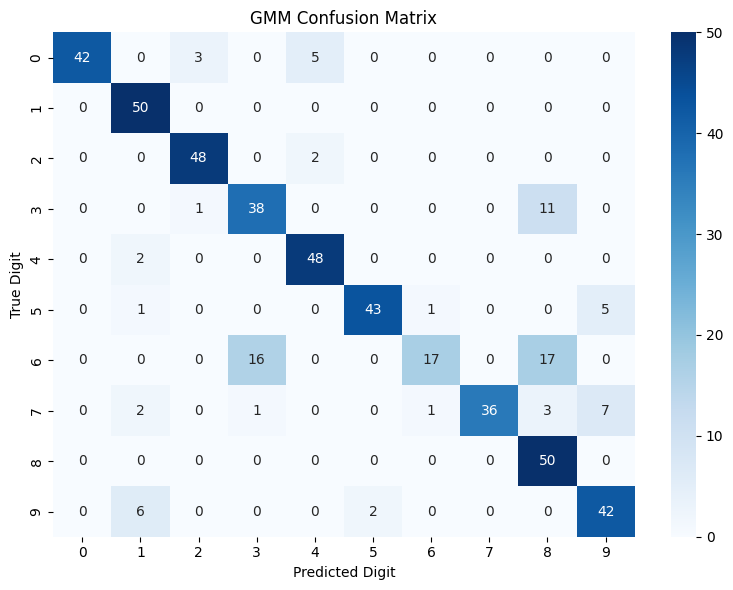

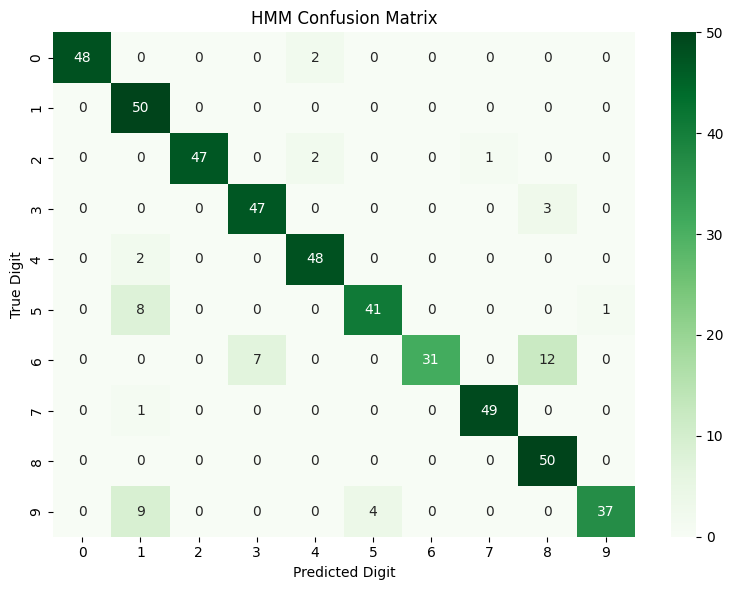

In [37]:
cm_gmm = confusion_matrix(yt_gmm, yp_gmm)
cm_hmm = confusion_matrix(yt_hmm, yp_hmm)

plot_confusion_matrix(cm_gmm, "GMM Confusion Matrix", "Blues")
plot_confusion_matrix(cm_hmm, "HMM Confusion Matrix", "Greens")


# Per-digit accuracy

In [38]:
print("\nGMM Per-digit Accuracy (Test):")
per_digit_accuracy(yt_gmm, yp_gmm)


GMM Per-digit Accuracy (Test):
  Digit 0: 0.840
  Digit 1: 1.000
  Digit 2: 0.960
  Digit 3: 0.760
  Digit 4: 0.960
  Digit 5: 0.860
  Digit 6: 0.340
  Digit 7: 0.720
  Digit 8: 1.000
  Digit 9: 0.840


In [39]:
print("\nHMM Per-digit Accuracy (Test):")
per_digit_accuracy(yt_hmm, yp_hmm)


HMM Per-digit Accuracy (Test):
  Digit 0: 0.960
  Digit 1: 1.000
  Digit 2: 0.940
  Digit 3: 0.940
  Digit 4: 0.960
  Digit 5: 0.820
  Digit 6: 0.620
  Digit 7: 0.980
  Digit 8: 1.000
  Digit 9: 0.740


In [40]:
gmm_per = [np.mean(yp_gmm[yt_gmm == d] == d) for d in range(10)]
hmm_per = [np.mean(yp_hmm[yt_hmm == d] == d) for d in range(10)]

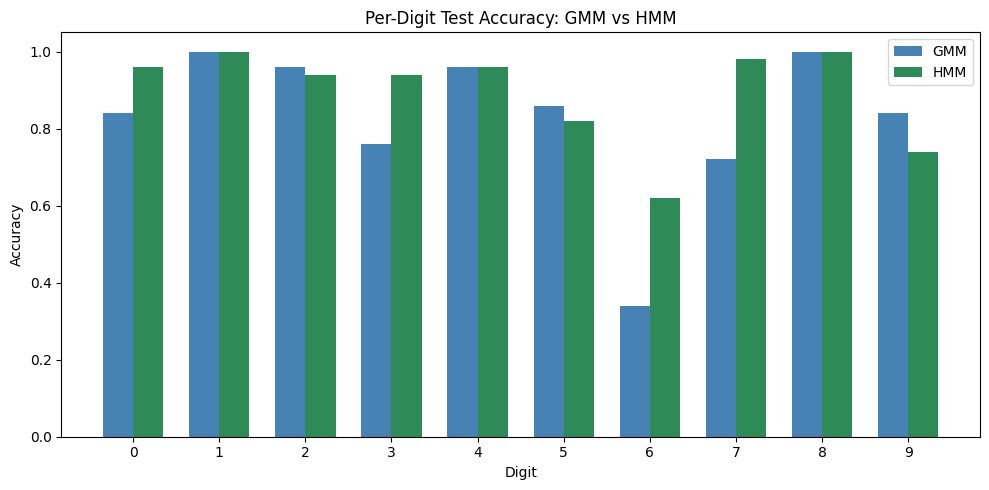

In [41]:
x = np.arange(10)
w = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, gmm_per, w, label="GMM", color="steelblue")
ax.bar(x + w/2, hmm_per, w, label="HMM", color="seagreen")
ax.set_xticks(x)
ax.set_xticklabels([str(d) for d in range(10)])
ax.set_xlabel("Digit")
ax.set_ylabel("Accuracy")
ax.set_title("Per-Digit Test Accuracy: GMM vs HMM")
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig("per_digit_accuracy_comparison.png", dpi=150)
plt.show()

In [42]:
print("\n===== FINAL COMPARISON =====")
print(f"GMM Test Accuracy : {acc_gmm:.4f}")
print(f"HMM Test Accuracy : {acc_hmm:.4f}")
print(f"HMM improvement   : {(acc_hmm - acc_gmm)*100:+.2f} percentage points")


===== FINAL COMPARISON =====
GMM Test Accuracy : 0.8280
HMM Test Accuracy : 0.8960
HMM improvement   : +6.80 percentage points
